In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [44]:
antiguedad = pd.read_csv("src/result/antiguitat_tipus_vehicle.csv")
poblacion = pd.read_csv("src/result/poblacion.csv")
renta = pd.read_csv("src/result/renta_distritos.csv")
tipos = pd.read_csv("src/result/tipus_vehicle.csv")
endolls = pd.read_csv("src/result/endolls.csv")

In [95]:
tipos = pd.DataFrame(tipos)
tipos

,Nom_Districte,Nom_Barri,Tipus_Propulsio,Unidades,Es_Electrico
0,Ciutat Vella,"Sant Pere, Santa Caterina i la Ribera",Diesel,2035,Otros
1,Ciutat Vella,"Sant Pere, Santa Caterina i la Ribera",Eléctrica,4084,Eléctrica
2,Ciutat Vella,"Sant Pere, Santa Caterina i la Ribera",Gasolina,7177,Otros
3,Ciutat Vella,"Sant Pere, Santa Caterina i la Ribera",Hibrido,536,Otros
4,Ciutat Vella,"Sant Pere, Santa Caterina i la Ribera",No consta,17,Otros
...,...,...,...,...,...
428,Sarrià-St. Gervasi,les Tres Torres,Eléctrica,306,Eléctrica
429,Sarrià-St. Gervasi,les Tres Torres,Gasolina,9038,Otros
430,Sarrià-St. Gervasi,les Tres Torres,Hibrido,841,Otros
431,Sarrià-St. Gervasi,les Tres Torres,No consta,14,Otros


In [97]:
df = poblacion.merge(renta, how="left", on=["Nom_Districte",])
df

,Unnamed: 0,Nom_Districte,Nom_Barri,Valor,Import_Euros
0,0,Ciutat Vella,"Sant Pere, Santa Caterina i la Ribera",20413,17033.31
1,1,Ciutat Vella,el Barri Gòtic,25609,17033.31
2,2,Ciutat Vella,el Raval,42429,17033.31
3,3,Ciutat Vella,la Barceloneta,13413,17033.31
4,4,Eixample,Sant Antoni,34703,26005.30
...,...,...,...,...,...
68,68,Sarrià-St. Gervasi,Sant Gervasi - la Bonanova,21935,35155.53
69,69,Sarrià-St. Gervasi,Sarrià,20240,35155.53
70,70,Sarrià-St. Gervasi,"Vallvidrera, el Tibidabo i les Planes",3922,35155.53
71,71,Sarrià-St. Gervasi,el Putxet i el Farró,25838,35155.53


In [98]:
df = df.drop("Unnamed: 0", axis=1)

In [100]:
df

,Nom_Districte,Nom_Barri,Valor,Import_Euros
0,Ciutat Vella,"Sant Pere, Santa Caterina i la Ribera",20413,17033.31
1,Ciutat Vella,el Barri Gòtic,25609,17033.31
2,Ciutat Vella,el Raval,42429,17033.31
3,Ciutat Vella,la Barceloneta,13413,17033.31
4,Eixample,Sant Antoni,34703,26005.30
...,...,...,...,...
68,Sarrià-St. Gervasi,Sant Gervasi - la Bonanova,21935,35155.53
69,Sarrià-St. Gervasi,Sarrià,20240,35155.53
70,Sarrià-St. Gervasi,"Vallvidrera, el Tibidabo i les Planes",3922,35155.53
71,Sarrià-St. Gervasi,el Putxet i el Farró,25838,35155.53


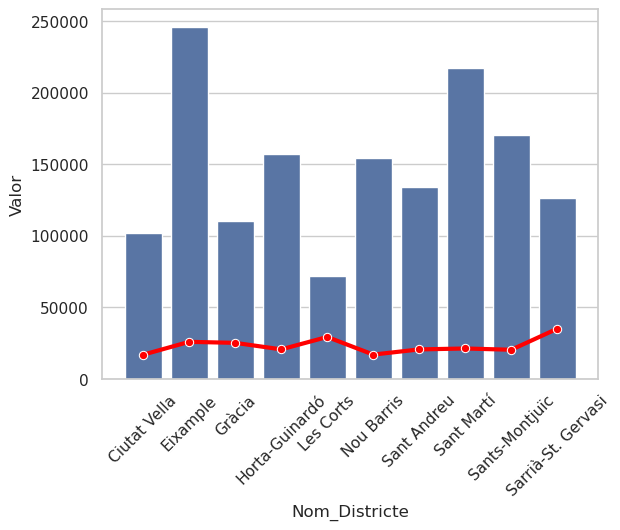

In [157]:
## Nº total de población por distritos

sns.barplot(df,x="Nom_Districte",y="Valor", errorbar=None, estimator=sum )
plt.xticks(rotation=45)
sns.lineplot(data=df, x="Nom_Districte", y="Import_Euros", 
             marker="o", color="red", linewidth=3, errorbar=None)
plt.show()

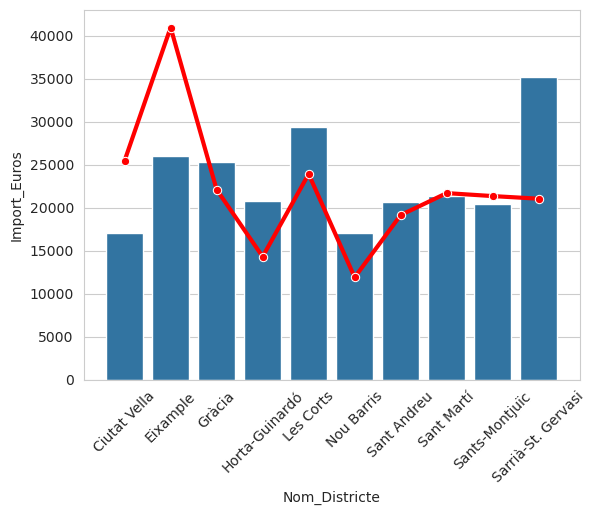

In [103]:
sns.barplot(df,x="Nom_Districte",y="Import_Euros", errorbar=None)
sns.lineplot(data=df, x="Nom_Districte", y="Valor",
             marker="o", color="red", linewidth=3, errorbar=None)
plt.xticks(rotation=45)
plt.show()

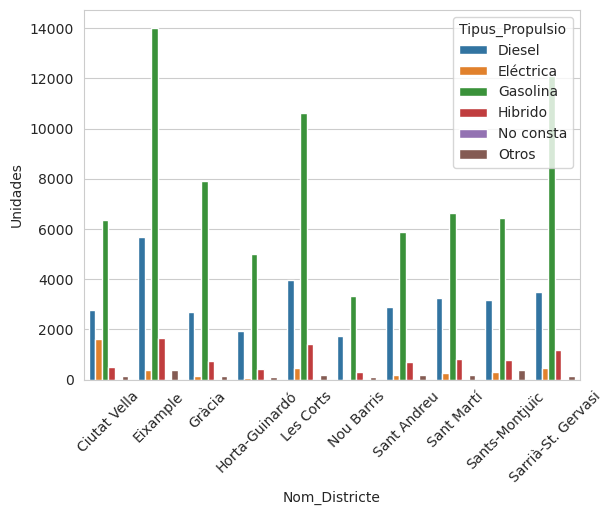

In [106]:
sns.barplot(data=tipos, x="Nom_Districte", y="Unidades", hue="Tipus_Propulsio", errorbar=None)
plt.xticks(rotation=45)
plt.show()

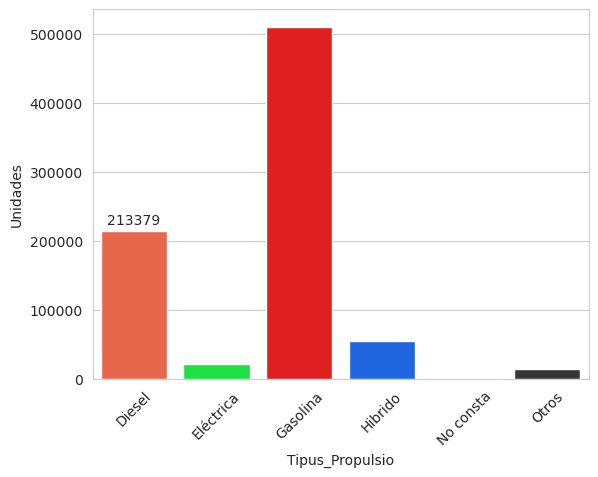

In [107]:
colores_personalizados = {
    "Diesel": "#FF5733",
    "Eléctrica": "#00FF2F",
    "Gasolina": "#FF0000",
    "Hibrido": "#005EFF",
    "No consta": "#FF0FBF",
    "Otros": "#373737"
}


sns.set_style("whitegrid")
ax = sns.barplot(data=tipos, x="Tipus_Propulsio", hue="Tipus_Propulsio", palette=colores_personalizados, y="Unidades", errorbar=None, estimator=sum)
ax.bar_label(ax.containers[0], padding=3, fmt='%.0f')
plt.xticks(rotation=45)
plt.show()

In [160]:
tipos.Unidades.sum()

np.int64(813455)

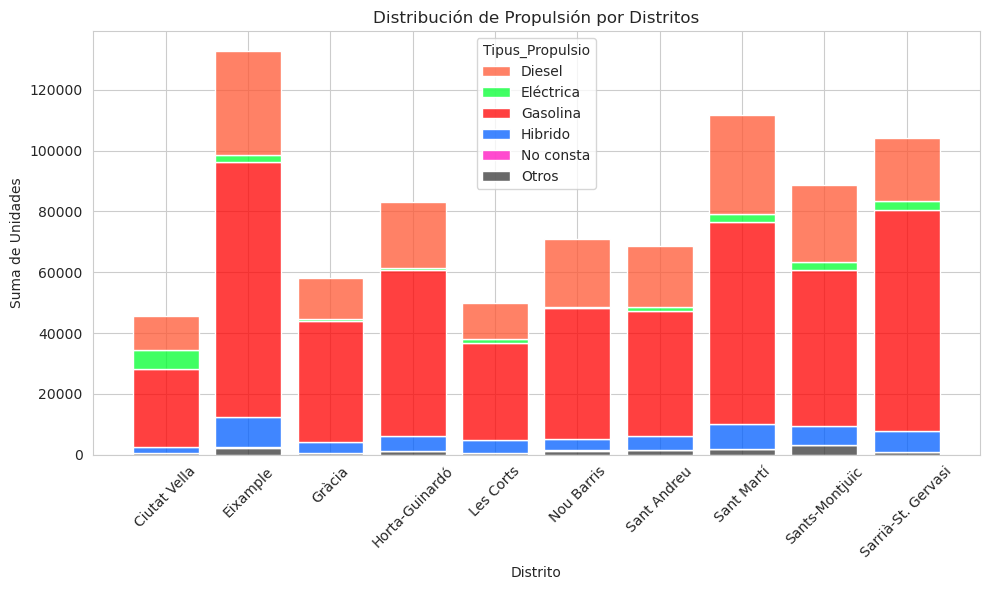

In [108]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=tipos,
    x='Nom_Districte',
    weights='Unidades', # Aquí indicas que la altura de la barra es el valor de "Unidades"
    hue='Tipus_Propulsio',
    multiple='stack',   # Esto es lo que pone todos en la misma columna
    palette=colores_personalizados,
    shrink=0.8          # Para que las barras no se peguen entre sí
)

plt.title("Distribución de Propulsión por Distritos")
plt.xticks(rotation=45)
plt.xlabel("Distrito")
plt.ylabel("Suma de Unidades")
plt.tight_layout()
plt.show()



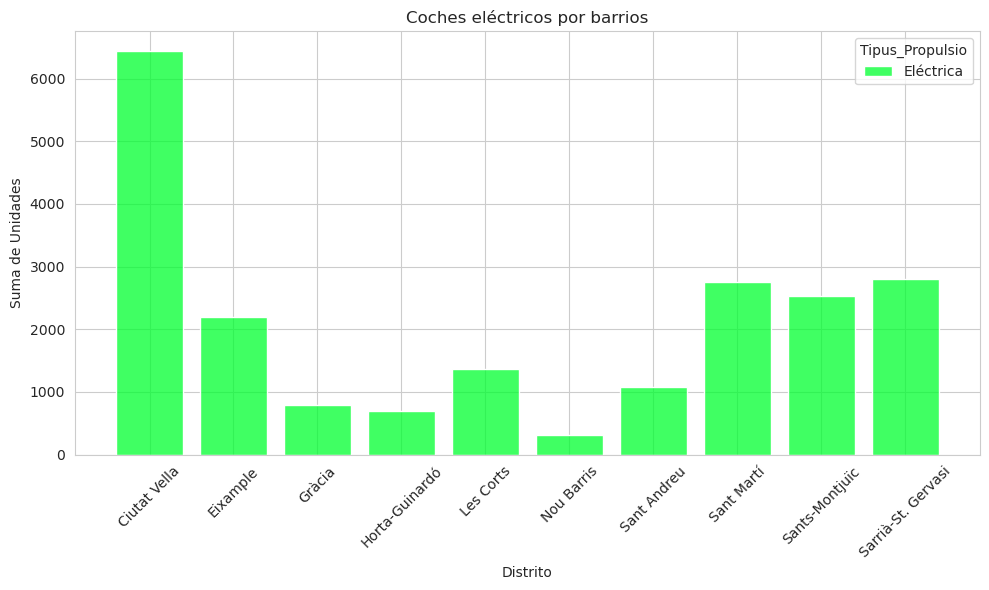

In [109]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=tipos[tipos['Tipus_Propulsio'] == 'Eléctrica'],
    x='Nom_Districte',
    weights='Unidades',
    hue='Tipus_Propulsio',
    multiple='stack',
    palette=colores_personalizados,
    shrink=0.8
)

plt.title("Coches eléctricos por barrios")
plt.xticks(rotation=45)
plt.xlabel("Distrito")
plt.ylabel("Suma de Unidades")
plt.tight_layout()
plt.show()


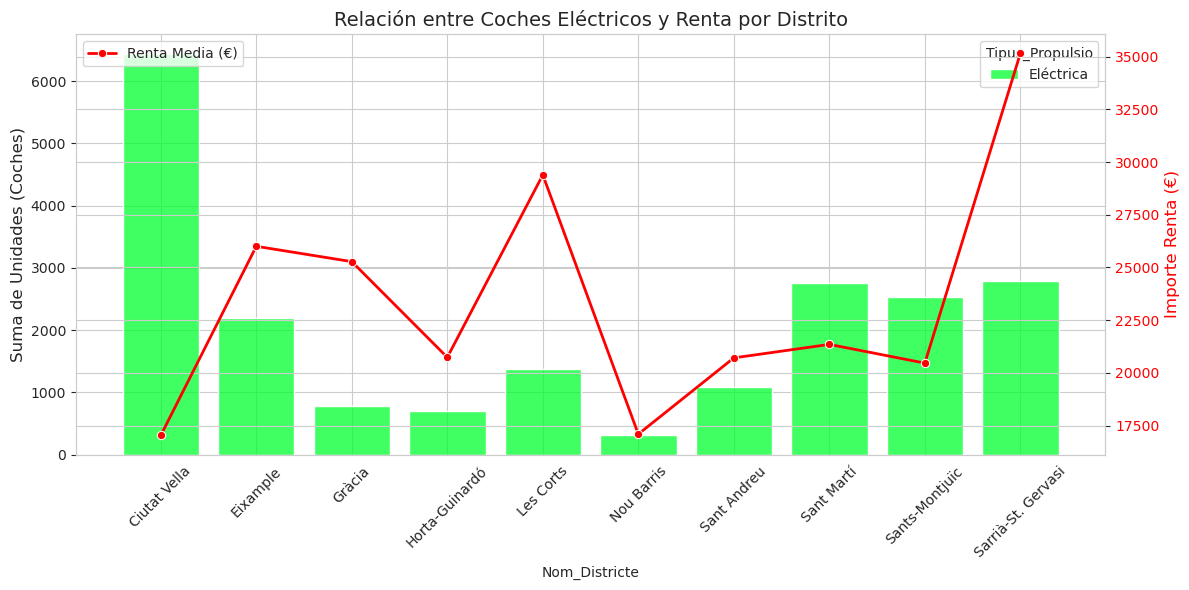

In [147]:
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=tipos[tipos['Tipus_Propulsio'] == 'Eléctrica'],
    x='Nom_Districte',
    weights='Unidades',
    hue='Tipus_Propulsio',
    multiple='stack',
    palette=colores_personalizados,
    shrink=0.8,
    ax=ax1
)
ax1.set_ylabel("Suma de Unidades (Coches)", fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax2 = ax1.twinx()
sns.lineplot(
    data=renta, 
    x="Nom_Districte", 
    y="Import_Euros", 
    ax=ax2, 
    color='red', 
    marker='o', 
    linewidth=2,
    label='Renta Media (€)'
)
ax2.set_ylabel("Importe Renta (€)", fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')
plt.title("Relación entre Coches Eléctricos y Renta por Distrito", fontsize=14)
fig.tight_layout()

plt.show()

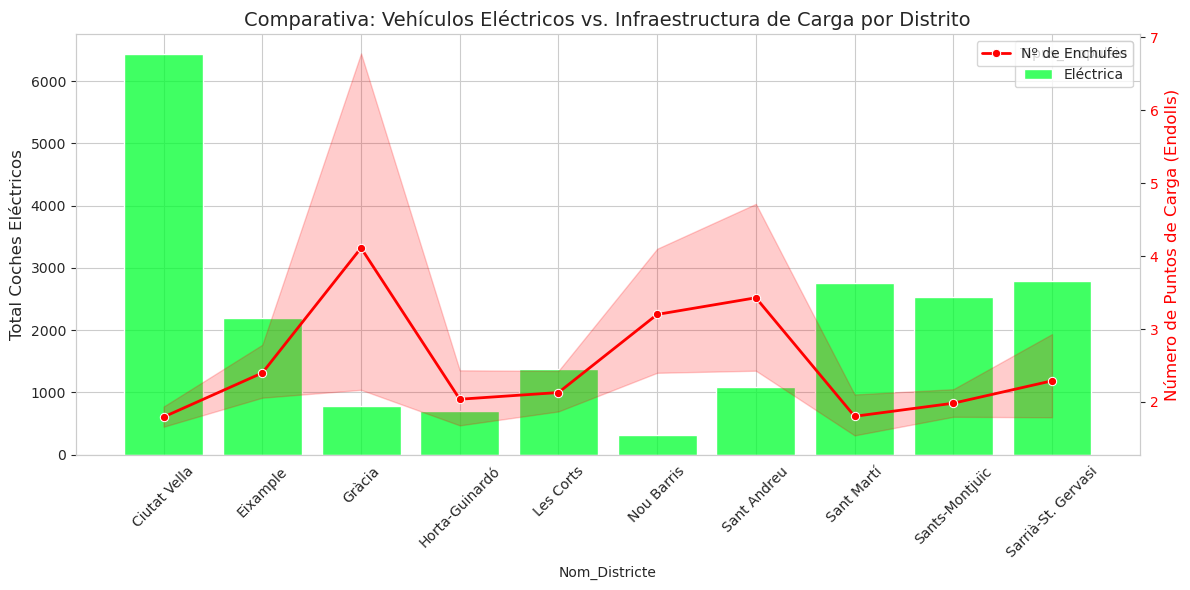

In [153]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. BARRAS: Coches Eléctricos (Eje Izquierdo)
sns.histplot(
    data=tipos[tipos['Tipus_Propulsio'] == 'Eléctrica'],
    x='Nom_Districte',
    weights='Unidades',
    hue='Tipus_Propulsio',
    multiple='stack',
    palette=colores_personalizados,
    shrink=0.8,
    ax=ax1
)
ax1.set_ylabel("Total Coches Eléctricos", fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# 2. SEGUNDO EJE Y (Para los enchufes)
ax2 = ax1.twinx()

# 3. LÍNEA: Cargadores (Eje Derecho)
sns.lineplot(
    data=endolls, 
    x="Distrito", 
    y="total_punts",
    ax=ax2, 
    color='red', 
    marker='o', 
    linewidth=2,
    label='Nº de Enchufes'
)

# CORRECCIÓN DE ETIQUETA: Ahora el eje derecho representa cargadores, no euros
ax2.set_ylabel("Número de Puntos de Carga (Endolls)", fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Eliminar el grid de ax2 para que no se superponga al de ax1
ax2.grid(False)

plt.title("Comparativa: Vehículos Eléctricos vs. Infraestructura de Carga por Distrito", fontsize=14)
fig.tight_layout()

plt.show()

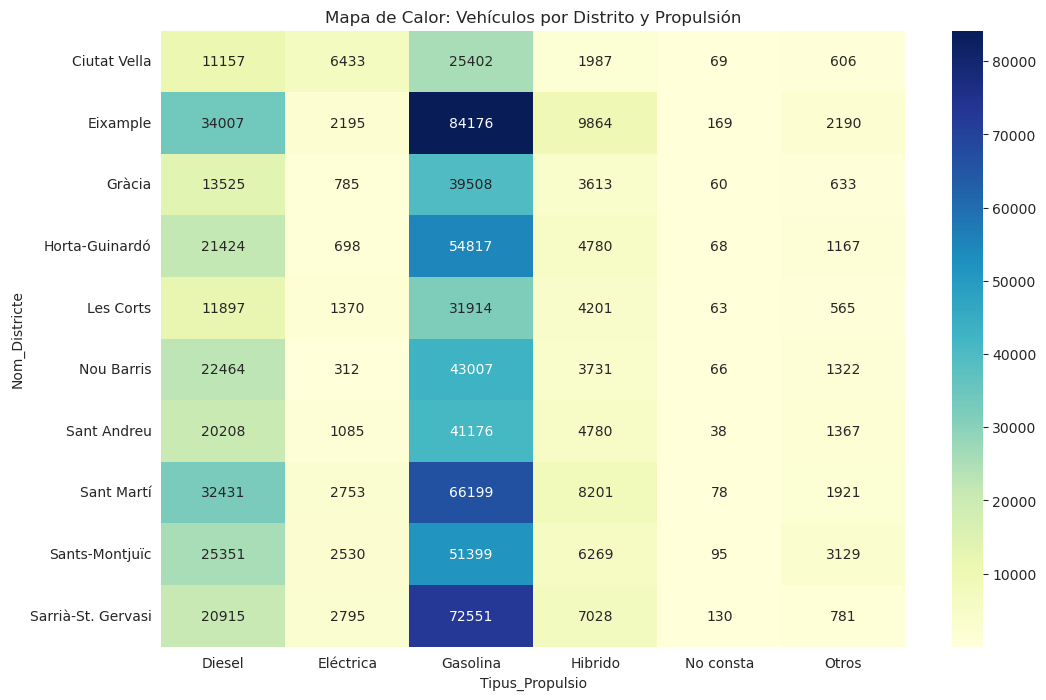

In [110]:
df_pivot = tipos.pivot_table(
    index='Nom_Districte', 
    columns='Tipus_Propulsio', 
    values='Unidades', 
    aggfunc='sum'
)

# 2. Dibujar el Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_pivot, annot=True, fmt=".0f", cmap="YlGnBu")

plt.title('Mapa de Calor: Vehículos por Distrito y Propulsión')
plt.show()

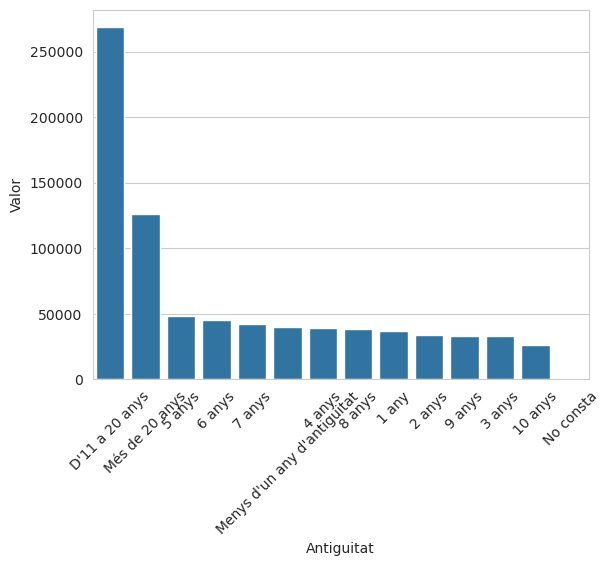

In [111]:
order = antiguedad.groupby("Antiguitat")["Valor"].sum().sort_values(ascending=False).index
sns.barplot(antiguedad,x="Antiguitat",y="Valor", errorbar=None, estimator=sum ,order=order)
plt.xticks(rotation=45)
plt.show()

In [112]:
def categorizar(antiguitat):
    if antiguitat in ["Menys d'un any d'antiguitat", "1 any", "2 anys", "3 anys", "4 anys"]:
        return "1. Nuevos (0-4)"
    elif antiguitat in ["5 anys", "6 anys", "7 anys", "8 anys", "9 anys", "10 anys"]:
        return "2. Medios (5-10)"
    elif antiguitat in ["D'11 a 20 anys", "Més de 20 anys"]:
        return "3. Antiguos (>10)"
    else:
        return "4. No consta"

# Crear la nueva columna
antiguedad['Categoria_Edat'] = antiguedad['Antiguitat'].apply(categorizar)

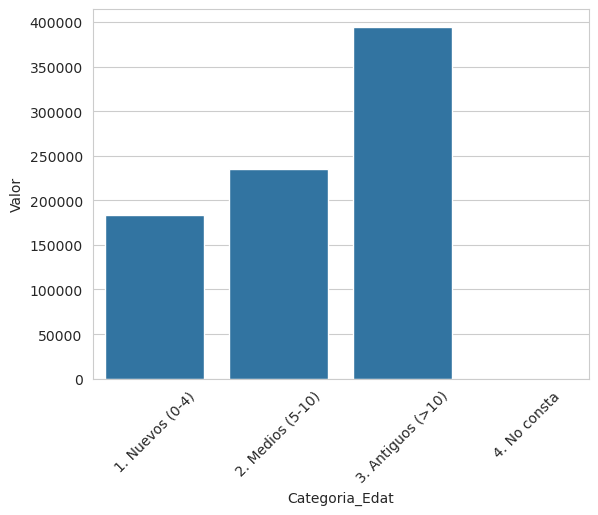

In [132]:
sns.barplot(antiguedad,x="Categoria_Edat",y="Valor", errorbar=None, estimator=sum)
plt.xticks(rotation=45)
plt.show()

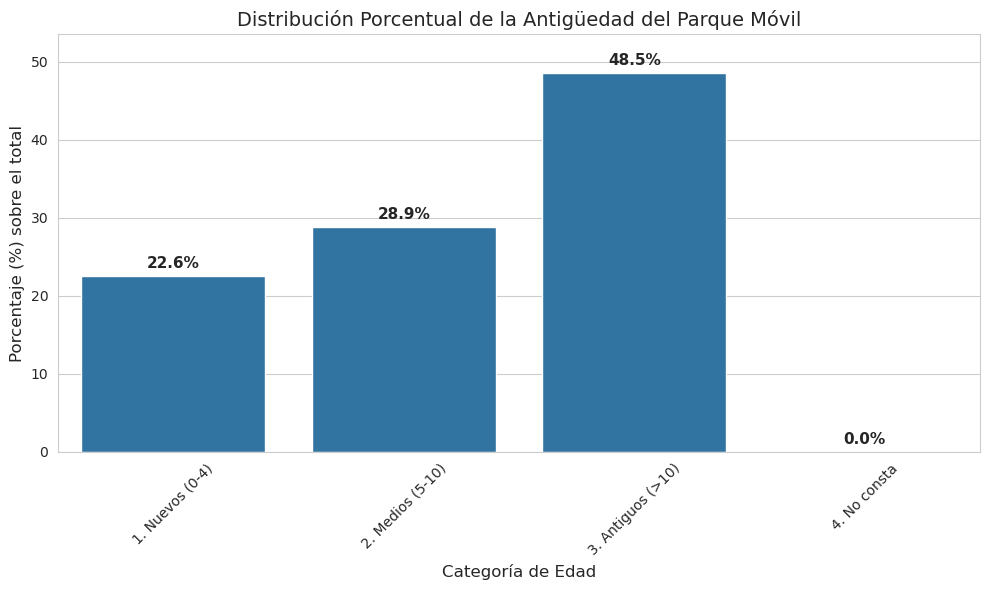

In [135]:
total_vehiculos = antiguedad['Valor'].sum()

# 2. Creamos el gráfico
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=antiguedad,
    x="Categoria_Edat",
    y="Valor",
    estimator=lambda x: (sum(x) / total_vehiculos) * 100, # Cálculo del %
    errorbar=None,
)

# 3. Añadir las etiquetas de texto con el % sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

# Configuración de etiquetas
plt.title("Distribución Porcentual de la Antigüedad del Parque Móvil", fontsize=14)
plt.xlabel("Categoría de Edad", fontsize=12)
plt.ylabel("Porcentaje (%) sobre el total", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, max([p.get_height() for p in ax.patches]) + 5) # Espacio para el texto
plt.tight_layout()
plt.show()

/tmp/ipykernel_11788/2667965041.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Edad del Vehículo", bbox_to_anchor=(1.05, 1), loc='upper left')


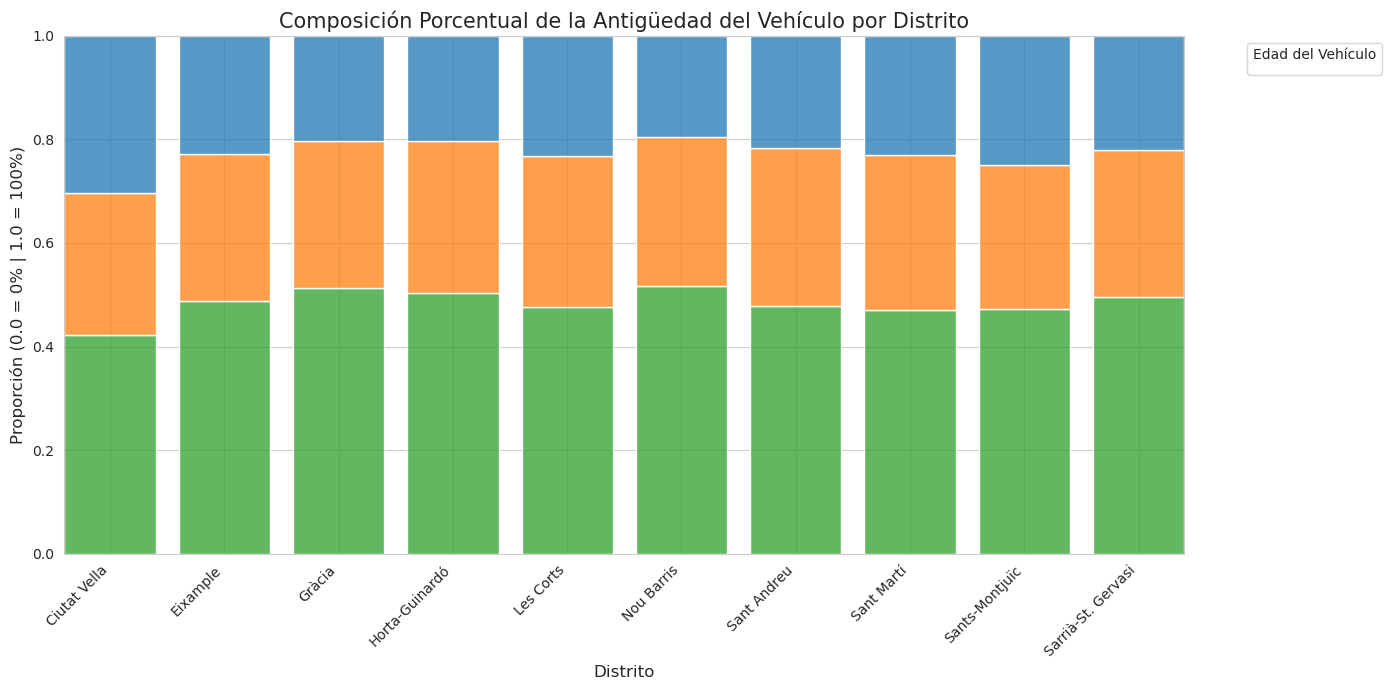

In [139]:
# 1. Filtramos los datos para quitar "No consta"
df_distritos = antiguedad[antiguedad['Nom_Districte'] != 'No consta']

# 2. Creamos el gráfico usando multiple='fill'
# Esto fuerza a que todas las barras midan lo mismo (1.0 o 100%)
# permitiendo comparar proporciones directamente.
plt.figure(figsize=(14, 7))

sns.histplot(
    data=df_distritos,
    x='Nom_Districte',
    weights='Valor',
    hue='Categoria_Edat',
    multiple='fill',
    shrink=0.8
)

# 3. Estética y etiquetas
plt.title("Composición Porcentual de la Antigüedad del Vehículo por Distrito", fontsize=15)
plt.xlabel("Distrito", fontsize=12)
plt.ylabel("Proporción (0.0 = 0% | 1.0 = 100%)", fontsize=12)
plt.xticks(rotation=45, ha='right')

# Mover la leyenda fuera para que no tape
plt.legend(title="Edad del Vehículo", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

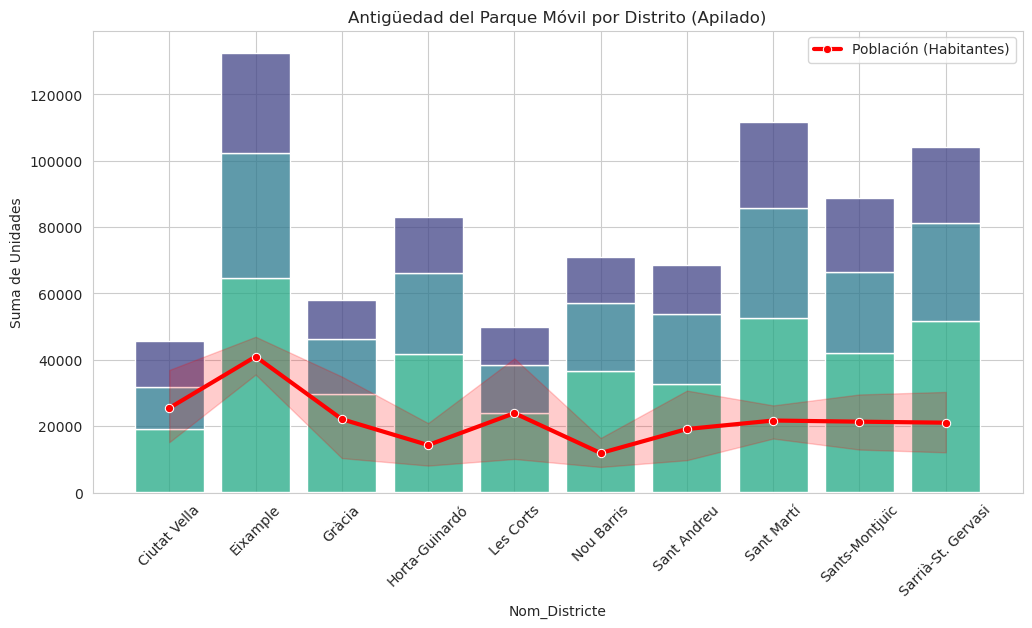

In [129]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=antiguedad[antiguedad['Nom_Districte'] != 'No consta'],
    x='Nom_Districte',
    weights='Valor',     # La columna con los números
    hue='Categoria_Edat',
    multiple='stack',    # <--- Esto es lo que "une" las barras hacia arriba
    palette='viridis',
    shrink=0.8           # Espacio entre los bloques de los distritos
)

plt.xticks(rotation=45)
plt.ylabel("Suma de Unidades")
plt.title("Antigüedad del Parque Móvil por Distrito (Apilado)")
sns.lineplot(poblacion,x="Nom_Districte", y="Valor", color='red', marker='o', label='Población (Habitantes)', linewidth=3, sort=False)
plt.show()

In [ ]:
endolls.drop("Unnamed: 0", axis=1, inplace=True)

In [115]:
endolls.head()


,nombre,tipo,direccion,type2,schuko,ccs2,chademo,cpostal,Distrito,total_punts
0,Parking TEKNON - SELBA EdRSR 1,Superficie,10 Carrer de la Marquesa de Vilallonga 08017,24,0,0,0,8017,Sarrià-St. Gervasi,24
1,Interparking Hispania/7169,Superficie,38 Carrer d'Esteve Terradas 08023,18,0,0,0,8023,Gràcia,18
2,Interparking Hispania/7169,Superficie,38 Carrer d'Esteve Terradas 08023,18,0,0,0,8023,Gràcia,18
3,"Av. Diagonal, 447 (lateral Mar)",Superficie,449 Avinguda Diagonal 08036,10,4,2,2,8036,Eixample,18
4,Interparking Hispania/6278,Superficie,9 Carrer de Casp 08010,12,0,0,0,8010,Eixample,12


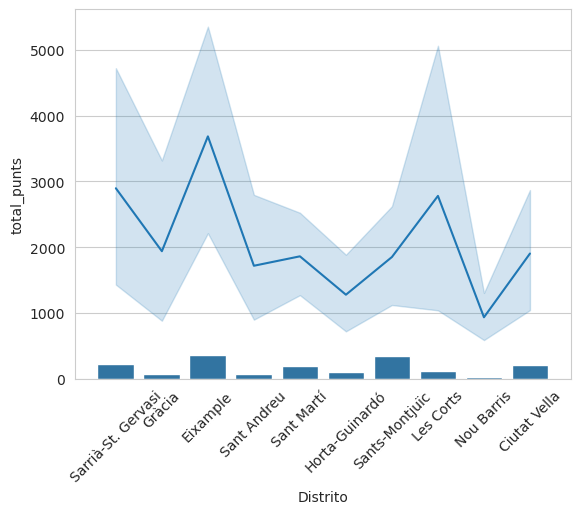

In [116]:
sns.barplot(endolls,x="Distrito",y="total_punts", errorbar=None ,estimator=sum)
sns.lineplot(tipos,x="Nom_Districte", y="Unidades")
plt.xticks(rotation=45)
plt.show()

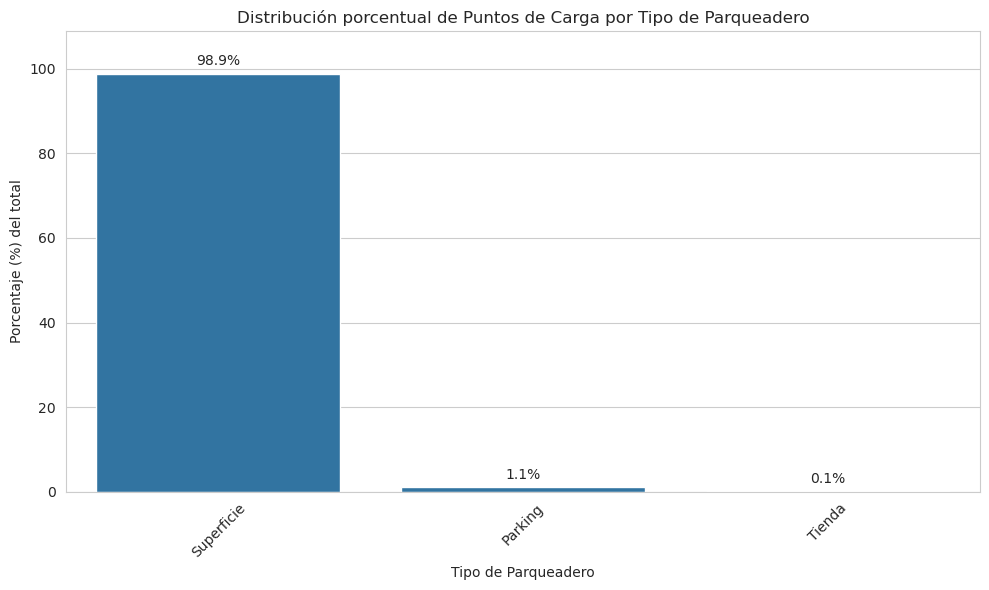

In [117]:
total_global = endolls['total_punts'].sum()

plt.figure(figsize=(10, 6))
ax = sns.barplot(endolls,x="tipo",y="total_punts",estimator=lambda x: (sum(x) / total_global) * 100, errorbar=None)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title("Distribución porcentual de Puntos de Carga por Tipo de Parqueadero")
plt.xlabel("Tipo de Parqueadero")
plt.ylabel("Porcentaje (%) del total")
plt.xticks(rotation=45)
plt.ylim(0, max([p.get_height() for p in ax.patches]) + 10) # Espacio para la etiqueta
plt.tight_layout()
plt.show()

In [ ]:
sns.barplot(endolls,)

/tmp/ipykernel_11788/1688441896.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


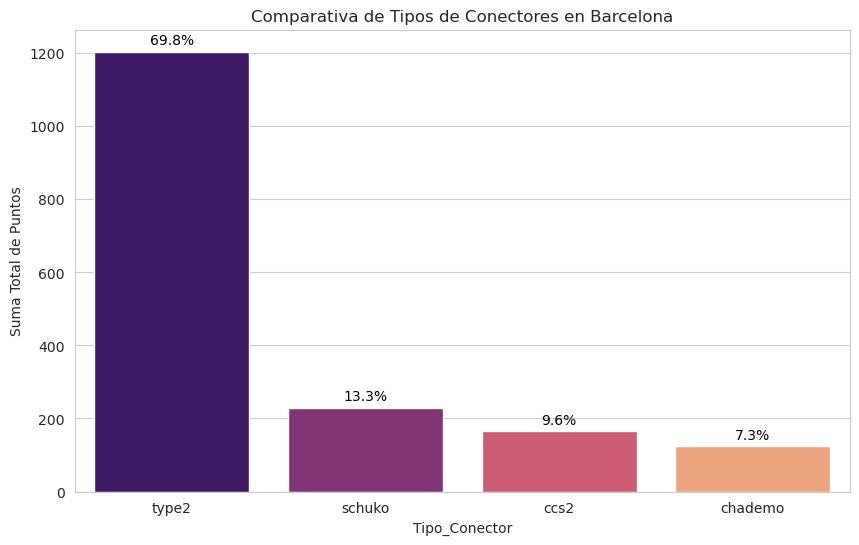

In [118]:
conectores = ['type2', 'schuko', 'ccs2', 'chademo']

# 'id_vars' son las columnas que se quedan fijas (como el distrito)
# 'value_vars' son las que se convierten en una sola columna de "tipo" y otra de "cantidad"
df_long = endolls.melt(id_vars=['Distrito'], 
                       value_vars=conectores, 
                       var_name='Tipo_Conector', 
                       value_name='Cantidad')

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_long,
    x='Tipo_Conector',
    y='Cantidad',
    estimator=sum,
    errorbar=None,
    palette='magma'
)

# Añadir los porcentajes sobre las barras
total = df_long['Cantidad'].sum()
ax = plt.gca()
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title("Comparativa de Tipos de Conectores en Barcelona")
plt.ylabel("Suma Total de Puntos")
plt.show()

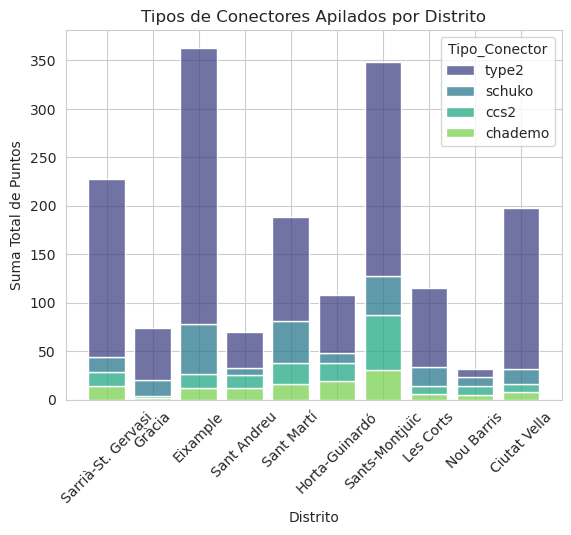

In [124]:


sns.histplot(
    data=df_long,
    x='Distrito',
    weights='Cantidad',
    hue='Tipo_Conector',
    multiple='stack',   # Aquí sí funciona perfectamente
    palette='viridis',
    shrink=0.8
)

plt.title("Tipos de Conectores Apilados por Distrito")
plt.xticks(rotation=45)
plt.ylabel("Suma Total de Puntos")
plt.show()

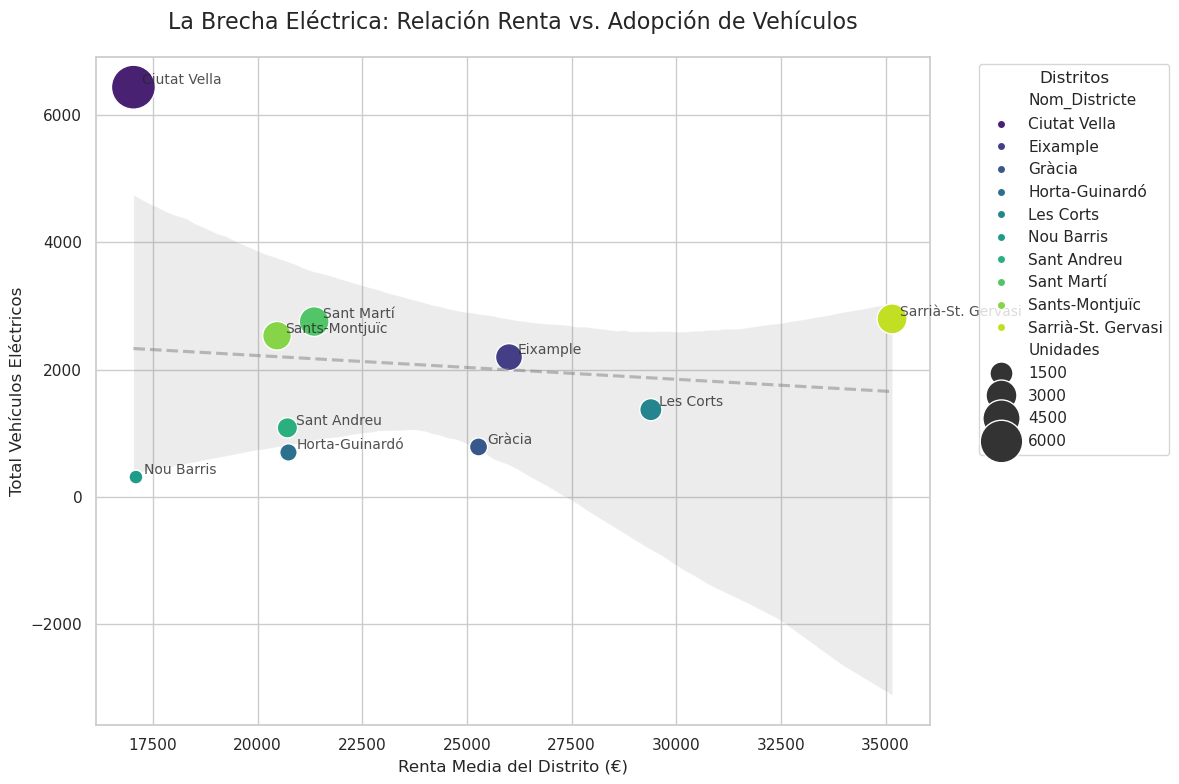

In [155]:

# Filtramos solo los eléctricos y sumamos por distrito
df_electrico = tipos[tipos['Tipus_Propulsio'] == 'Eléctrica'].groupby('Nom_Districte')['Unidades'].sum().reset_index()
df_brecha = df_electrico.merge(renta, on='Nom_Districte')

# 2. Configuración estética
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# 3. Gráfico de Regresión (Muestra la tendencia de la brecha)
sns.regplot(
    data=df_brecha,
    x='Import_Euros',
    y='Unidades',
    scatter=False,
    color='gray',
    line_kws={"ls": "--", "alpha": 0.5}
)

# 4. Puntos por distrito
plot = sns.scatterplot(
    data=df_brecha,
    x='Import_Euros',
    y='Unidades',
    hue='Nom_Districte',
    size='Unidades',
    sizes=(100, 1000),
    palette='viridis',
    legend='brief'
)

# 5. Etiquetas de nombres para cada punto
for i in range(df_brecha.shape[0]):
    plt.text(
        df_brecha.Import_Euros[i] + 200, 
        df_brecha.Unidades[i] + 50, 
        df_brecha.Nom_Districte[i], 
        fontsize=10, 
        alpha=0.8
    )

# 6. Personalización final
plt.title("La Brecha Eléctrica: Relación Renta vs. Adopción de Vehículos", fontsize=16, pad=20)
plt.xlabel("Renta Media del Distrito (€)", fontsize=12)
plt.ylabel("Total Vehículos Eléctricos", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Distritos")

plt.tight_layout()
plt.show()